# 06 - Model Comparison v1 vs v2 (ITG Stamina)

**ES:** Este notebook compara el modelo ganador antes de la hiperparametrizacion (`stamina_model_v1.pkl`, Random Forest) contra el modelo ganador despues de la hiperparametrizacion (`stamina_model_v2.pkl`, Gradient Boosting).

**EN:** This notebook compares the winning model before hyperparameter tuning (`stamina_model_v1.pkl`, Random Forest) against the winning model after tuning (`stamina_model_v2.pkl`, Gradient Boosting).

## Objetivo / Objective
- Evaluar ambos modelos con el mismo conjunto de features y el mismo dataset.
- Comparar MAE, R2 y accuracy por tolerancias (plus-minus 0.25, 0.50, 1.00).
- Analizar distribucion de errores y comportamiento por dificultad.
- Exportar una tabla comparativa para reportes de tesis.

## 1) Imports / Importaciones

In [10]:
from __future__ import annotations

from pathlib import Path
from typing import Any

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, r2_score

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_colwidth', 120)

print('Imports loaded successfully.')

Imports loaded successfully.


## 2) Data loading / Carga de datos

Usamos exactamente el mismo set de features de produccion definido en notebooks 04 y 05 para comparabilidad metodologica.

In [11]:
NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != 'notebooks':
    NOTEBOOK_DIR = Path('../ml-core/notebooks').resolve()

CORE_DIR = NOTEBOOK_DIR.parent
PROCESSED_DIR = CORE_DIR / 'data' / 'processed'
MODELS_DIR = CORE_DIR / 'models'

dataset_path = PROCESSED_DIR / 'stamina_dataset.csv'
df = pd.read_csv(dataset_path)

drop_columns = [col for col in ['average_nps', 'ebpm'] if col in df.columns]
df_model = df.drop(columns=drop_columns)

if 'display_BPM' in df_model.columns:
    bpm_column = 'display_BPM'
elif 'display_bpm' in df_model.columns:
    bpm_column = 'display_bpm'
else:
    raise KeyError("Neither 'display_BPM' nor 'display_bpm' exists in the dataset columns.")

feature_columns = [
    'total_stream_length',
    'max_stream_length',
    'break_count',
    'stream_break_ratio',
    bpm_column,
]

X = df_model[feature_columns].copy().fillna(0)
X = X.rename(columns={bpm_column: 'display_BPM'})
y = df_model['difficulty'].copy()

print(f'Dataset: {dataset_path}')
print(f'Shape X: {X.shape} | Shape y: {y.shape}')
print(f'Features used: {list(X.columns)}')

Dataset: c:\Users\maru\Documents\Uni\Tesina\ITGStamina-rater-ml\ml-core\data\processed\stamina_dataset.csv
Shape X: (2852, 5) | Shape y: (2852,)
Features used: ['total_stream_length', 'max_stream_length', 'break_count', 'stream_break_ratio', 'display_BPM']


## 3) Load exported models / Carga de modelos exportados

In [12]:
model_v1_path = MODELS_DIR / 'stamina_model_v1.pkl'
model_v2_path = MODELS_DIR / 'stamina_model_v2.pkl'

if not model_v1_path.exists():
    raise FileNotFoundError(f'Model file not found: {model_v1_path}')
if not model_v2_path.exists():
    raise FileNotFoundError(f'Model file not found: {model_v2_path}')

model_v1 = joblib.load(model_v1_path)
model_v2 = joblib.load(model_v2_path)

print(f'Loaded: {model_v1_path.name}')
print(f'Loaded: {model_v2_path.name}')

Loaded: stamina_model_v1.pkl
Loaded: stamina_model_v2.pkl


## 4) Metrics / Metricas

In [13]:
def tolerance_accuracy_summary(
    y_true: pd.Series | np.ndarray,
    y_pred: np.ndarray,
    tolerances: tuple[float, ...] = (0.25, 0.50, 1.00),
) -> dict[str, float]:
    """
    EN: Compute cumulative accuracies for multiple absolute-error tolerances.
    ES: Calcula accuracies acumuladas para multiples tolerancias de error absoluto.
    """
    y_true_array = np.asarray(y_true)
    y_pred_array = np.asarray(y_pred)
    abs_error = np.abs(y_true_array - y_pred_array)

    return {
        f'Acc +/-{tol:.2f} (%)': float(np.mean(abs_error <= tol) * 100.0)
        for tol in tolerances
    }


def absolute_error_bands(y_true: pd.Series | np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    """
    EN: Break down percentage of samples across absolute-error bands.
    ES: Desglosa el porcentaje de muestras por bandas de error absoluto.
    """
    y_true_array = np.asarray(y_true)
    y_pred_array = np.asarray(y_pred)
    abs_error = np.abs(y_true_array - y_pred_array)

    return {
        'Err <=0.25 (%)': float(np.mean(abs_error <= 0.25) * 100.0),
        'Err (0.25,0.50] (%)': float(np.mean((abs_error > 0.25) & (abs_error <= 0.50)) * 100.0),
        'Err (0.50,1.00] (%)': float(np.mean((abs_error > 0.50) & (abs_error <= 1.00)) * 100.0),
        'Err >1.00 (%)': float(np.mean(abs_error > 1.00) * 100.0),
    }


def regression_metrics_bundle(
    model_name: str,
    y_true: pd.Series | np.ndarray,
    y_pred: np.ndarray,
) -> dict[str, float | str]:
    """
    EN: Build a full metrics dictionary for a model comparison row.
    ES: Construye un diccionario completo de metricas para una fila de comparacion de modelos.
    """
    metrics: dict[str, float | str] = {
        'Model': model_name,
        'MAE': float(mean_absolute_error(y_true, y_pred)),
        'R2': float(r2_score(y_true, y_pred)),
    }
    metrics.update(tolerance_accuracy_summary(y_true, y_pred))
    metrics.update(absolute_error_bands(y_true, y_pred))
    return metrics


print('Metric helpers ready.')

Metric helpers ready.


## 5) Full-data comparison / Comparacion en todo el dataset

**ES:** Esta comparacion usa modelos ya entrenados sobre el dataset completo, por lo que se interpreta como comparacion descriptiva **in-sample**.

**EN:** This comparison uses models already trained on the full dataset, so it should be interpreted as a descriptive **in-sample** comparison.

**ES:** Es util para diagnostico de errores y comportamiento relativo entre v1 y v2 en este dataset, pero no reemplaza la evidencia de generalizacion del notebook 05.

**EN:** It is useful for error diagnostics and relative behavior between v1 and v2 on this dataset, but it does not replace notebook 05 generalization evidence.

In [14]:
pred_v1 = model_v1.predict(X)
pred_v2 = model_v2.predict(X)

summary_rows = [
    regression_metrics_bundle('Random Forest (v1)', y, pred_v1),
    regression_metrics_bundle('Gradient Boosting (v2)', y, pred_v2),
]

comparison_summary_df = pd.DataFrame(summary_rows).sort_values('MAE', ascending=True).reset_index(drop=True)
comparison_summary_df

,Model,MAE,R2,Acc +/-0.25 (%),Acc +/-0.50 (%),Acc +/-1.00 (%),Err <=0.25 (%),"Err (0.25,0.50] (%)","Err (0.50,1.00] (%)",Err >1.00 (%)
0,Random Forest (v1),0.121395,0.999141,86.711080,98.492286,99.789621,86.711080,11.781206,1.297335,0.210379
1,Gradient Boosting (v2),0.200992,0.998065,69.985975,94.775596,99.719495,69.985975,24.789621,4.943899,0.280505


In [15]:
error_df = pd.DataFrame({
    'difficulty': y.astype(float),
    'pred_v1': pred_v1,
    'pred_v2': pred_v2,
})
error_df['abs_err_v1'] = (error_df['difficulty'] - error_df['pred_v1']).abs()
error_df['abs_err_v2'] = (error_df['difficulty'] - error_df['pred_v2']).abs()
error_df['delta_abs_err_v2_minus_v1'] = error_df['abs_err_v2'] - error_df['abs_err_v1']

print('Rows where v2 improves over v1 (%):', round(float((error_df['delta_abs_err_v2_minus_v1'] < 0).mean() * 100), 2))
print('Rows where v1 improves over v2 (%):', round(float((error_df['delta_abs_err_v2_minus_v1'] > 0).mean() * 100), 2))
print('Rows with tie (%):', round(float((error_df['delta_abs_err_v2_minus_v1'] == 0).mean() * 100), 2))

Rows where v2 improves over v1 (%): 24.86
Rows where v1 improves over v2 (%): 75.14
Rows with tie (%): 0.0


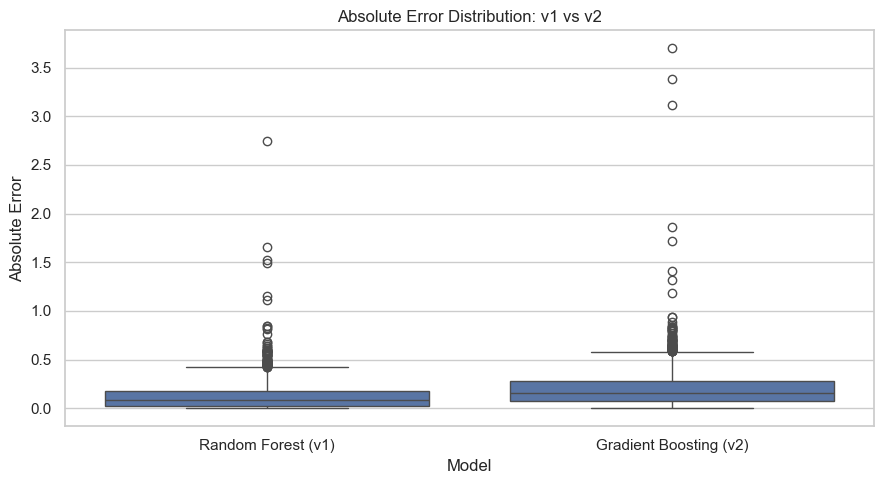

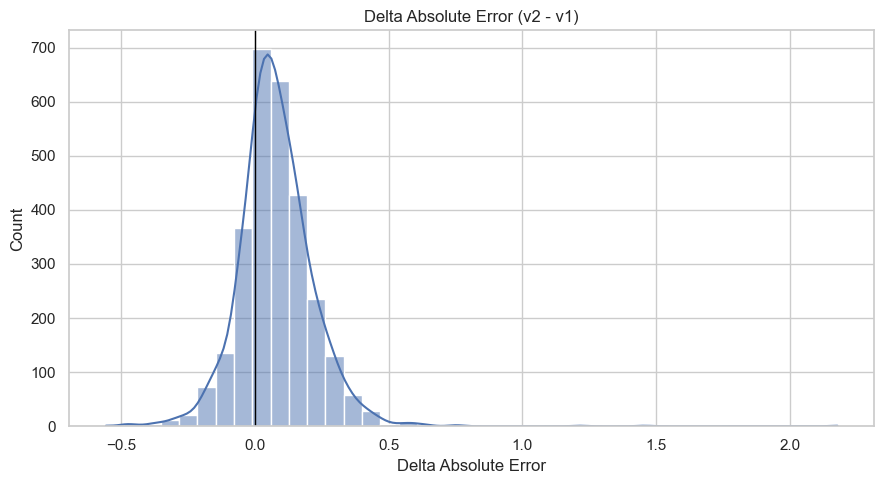

In [16]:
plot_df = pd.DataFrame({
    'Random Forest (v1)': error_df['abs_err_v1'],
    'Gradient Boosting (v2)': error_df['abs_err_v2'],
}).melt(var_name='Model', value_name='Absolute Error')

plt.figure(figsize=(9, 5))
sns.boxplot(data=plot_df, x='Model', y='Absolute Error')
plt.title('Absolute Error Distribution: v1 vs v2')
plt.xlabel('Model')
plt.ylabel('Absolute Error')
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
sns.histplot(error_df['delta_abs_err_v2_minus_v1'], bins=40, kde=True)
plt.axvline(0.0, color='black', linewidth=1.0)
plt.title('Delta Absolute Error (v2 - v1)')
plt.xlabel('Delta Absolute Error')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [17]:
export_summary_path = PROCESSED_DIR / 'model_comparison_v1_vs_v2_summary.csv'
export_detail_path = PROCESSED_DIR / 'model_comparison_v1_vs_v2_detail.csv'

comparison_summary_df.to_csv(export_summary_path, index=False)
error_df.to_csv(export_detail_path, index=False)

print(f'Exported summary: {export_summary_path.resolve()}')
print(f'Exported detail: {export_detail_path.resolve()}')

Exported summary: C:\Users\maru\Documents\Uni\Tesina\ITGStamina-rater-ml\ml-core\data\processed\model_comparison_v1_vs_v2_summary.csv
Exported detail: C:\Users\maru\Documents\Uni\Tesina\ITGStamina-rater-ml\ml-core\data\processed\model_comparison_v1_vs_v2_detail.csv


## 6) Reading the comparison / Como leer la comparacion

**ES:**
- Si v2 muestra menor MAE y menor porcentaje de `Err >1.00 (%)`, aporta mejor precision practica en este corte descriptivo.
- Si la distribucion `delta_abs_err_v2_minus_v1` se concentra por debajo de 0, v2 mejora en una mayor fraccion de charts en este dataset.
- Esta seccion es **in-sample**: sirve para analisis diagnostico, no para reclamar superioridad de generalizacion por si sola.
- Para conclusion de uso real (generalizacion), priorizar notebook 05 (Nested CV, out-of-sample).

**EN:**
- If v2 shows lower MAE and lower `Err >1.00 (%)`, it offers better practical precision for this descriptive slice.
- If `delta_abs_err_v2_minus_v1` concentrates below 0, v2 improves on a larger fraction of charts in this dataset.
- This section is **in-sample**: useful for diagnostics, not sufficient alone to claim generalization superiority.
- For real-world generalization conclusions, prioritize notebook 05 (Nested CV, out-of-sample).

## 7) Statistical significance / Significancia estadistica

**ES:** Esta seccion evalua si la diferencia de error entre v2 y v1 es estadisticamente consistente o puede explicarse por variabilidad muestral.

**EN:** This section checks whether the error difference between v2 and v1 is statistically consistent or can be explained by sampling variability.

Metodologia:
- Bootstrap pareado sobre el delta de error absoluto (`v2 - v1`) para intervalo de confianza del promedio.
- Permutation test pareado (sign-flip) para p-value bilateral bajo hipotesis nula de diferencia media cero.

In [18]:
# EN: Statistical comparison on paired absolute errors (v2 - v1).
# ES: Comparacion estadistica sobre errores absolutos pareados (v2 - v1).
diff = error_df['delta_abs_err_v2_minus_v1'].to_numpy(dtype=float)
observed_mean_delta = float(diff.mean())

BOOTSTRAP_ITER = 5000
PERMUTATION_ITER = 5000
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

n = diff.size
bootstrap_means = np.empty(BOOTSTRAP_ITER, dtype=float)
for i in range(BOOTSTRAP_ITER):
    sample_idx = rng.integers(0, n, size=n)
    bootstrap_means[i] = float(diff[sample_idx].mean())

ci_low, ci_high = np.percentile(bootstrap_means, [2.5, 97.5])

perm_means = np.empty(PERMUTATION_ITER, dtype=float)
for i in range(PERMUTATION_ITER):
    signs = rng.choice(np.array([-1.0, 1.0]), size=n)
    perm_means[i] = float((diff * signs).mean())

p_value_two_sided = float(np.mean(np.abs(perm_means) >= abs(observed_mean_delta)))

improve_rate = float(np.mean(diff < 0) * 100.0)
worse_rate = float(np.mean(diff > 0) * 100.0)
tie_rate = float(np.mean(diff == 0) * 100.0)

stats_df = pd.DataFrame([
    {
        'Observed mean delta (v2-v1)': observed_mean_delta,
        '95% CI low': float(ci_low),
        '95% CI high': float(ci_high),
        'Permutation p-value (two-sided)': p_value_two_sided,
        'v2 improves (%)': improve_rate,
        'v1 improves (%)': worse_rate,
        'tie (%)': tie_rate,
        'n_samples': int(n),
        'bootstrap_iter': int(BOOTSTRAP_ITER),
        'permutation_iter': int(PERMUTATION_ITER),
    }
])

display(stats_df)

if ci_high < 0 and p_value_two_sided < 0.05:
    conclusion = 'v2 statistically outperforms v1 (lower absolute error).'
elif ci_low > 0 and p_value_two_sided < 0.05:
    conclusion = 'v1 statistically outperforms v2 (lower absolute error).'
else:
    conclusion = 'Difference is not statistically conclusive at alpha=0.05.'

print('Conclusion:', conclusion)

stats_output_path = PROCESSED_DIR / 'model_comparison_v1_vs_v2_significance.csv'
stats_df.to_csv(stats_output_path, index=False)
print(f'Exported significance summary: {stats_output_path.resolve()}')

,Observed mean delta (v2-v1),95% CI low,95% CI high,Permutation p-value (two-sided),v2 improves (%),v1 improves (%),tie (%),n_samples,bootstrap_iter,permutation_iter
0,0.079597,0.074287,0.085036,0.0,24.859748,75.140252,0.0,2852,5000,5000


Conclusion: v1 statistically outperforms v2 (lower absolute error).
Exported significance summary: C:\Users\maru\Documents\Uni\Tesina\ITGStamina-rater-ml\ml-core\data\processed\model_comparison_v1_vs_v2_significance.csv
